# Groupe 16

    - KAMDOM NGUETCHESSI MERVEILLE PRISCA 23V2060
    - KENNE YEMTSA LOWEL RAYANN 23U2477
    - YOKO AYMERICK JEFFREY 23U2983

# Installation des dépendances (Requirements)

Avant de commencer, nous nous assurons que toutes les bibliothèques requises sont installées avec les bonnes versions pour garantir la reproductibilité du code. Un fichier **requirements.txt** est deja fourni avec les informations sur les bibliotheques a installer.

In [1]:
!pip install -r requirements.txt

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai


# Importation des bibliothèques

Nous importons ici l'ensemble des modules nécessaires pour l'extraction, la manipulation des données (Pandas, Numpy), la visualisation (Matplotlib, Seaborn) et le Machine Learning (Scikit-Learn).

In [1]:
import os
import glob
import zipfile
import tarfile
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

# Extraction Automatisée des Données
Nos données brutes se trouvent dans des archives compressées de la Banque Mondiale. Ce script parcourt le dossier source, identifie le format de l'archive (.zip) et extrait chaque pays dans un sous-dossier propre au sein du répertoire cible ExtractedDS.

Dans notre pipeline, les donnees en archive etait contenu dans le repertoire Archive. Veuillez modifier le repertoire pour inclure le votre ou passez a la cellule qui recupere les donnees dans le dataset CSV extrait.

In [2]:
def extraire_archives(repertoire_source, repertoire_destination):
    if not os.path.exists(repertoire_destination):
        os.makedirs(repertoire_destination)
        print(f"Répertoire créé : {repertoire_destination}")

    fichiers = [f for f in os.listdir(repertoire_source) if os.path.isfile(os.path.join(repertoire_source, f))]
    
    for fichier in fichiers:
        chemin_complet = os.path.join(repertoire_source, fichier)
        nom_dossier_pays = os.path.splitext(fichier)[0]
        cible_extraction = os.path.join(repertoire_destination, nom_dossier_pays)

        try:
            if fichier.lower().endswith('.zip'):
                with zipfile.ZipFile(chemin_complet, 'r') as zip_ref:
                    os.makedirs(cible_extraction, exist_ok=True)
                    zip_ref.extractall(cible_extraction)
                print(f" Extrait (ZIP) : {fichier}")

            elif fichier.lower().endswith(('.tar.gz', '.tgz')):
                with tarfile.open(chemin_complet, 'r:gz') as tar_ref:
                    os.makedirs(cible_extraction, exist_ok=True)
                    tar_ref.extractall(cible_extraction)
                print(f" Extrait (TAR) : {fichier}")

        except Exception as e:
            print(f"Erreur lors de l'extraction de {fichier} : {e}")

SOURCE = "./Archive" # <-- Modifie cette ligne pour inclure votre repertoire de donnees archive
DESTINATION = "./ExtractedDS"          

extraire_archives(SOURCE, DESTINATION)

✓ Extrait (ZIP) : API_CMR_DS2_fr_csv_v2_23757.zip
✓ Extrait (ZIP) : API_PHL_DS2_fr_csv_v2_27619.zip
✓ Extrait (ZIP) : API_UZB_DS2_fr_csv_v2_35979.zip
✓ Extrait (ZIP) : API_SUR_DS2_fr_csv_v2_27236.zip
✓ Extrait (ZIP) : API_CAF_DS2_fr_csv_v2_18666.zip
✓ Extrait (ZIP) : API_PRK_DS2_fr_csv_v2_56428.zip
✓ Extrait (ZIP) : API_FIN_DS2_fr_csv_v2_18405.zip
✓ Extrait (ZIP) : API_MYS_DS2_fr_csv_v2_136172.zip
✓ Extrait (ZIP) : API_QAT_DS2_fr_csv_v2_56270.zip
✓ Extrait (ZIP) : API_TTO_DS2_fr_csv_v2_121179.zip
✓ Extrait (ZIP) : API_PRI_DS2_fr_csv_v2_18224.zip
✓ Extrait (ZIP) : API_ROU_DS2_fr_csv_v2_18574.zip
✓ Extrait (ZIP) : API_BLZ_DS2_fr_csv_v2_56421.zip
✓ Extrait (ZIP) : API_SEN_DS2_fr_csv_v2_18353.zip
✓ Extrait (ZIP) : API_GRD_DS2_fr_csv_v2_56278.zip
✓ Extrait (ZIP) : API_MNG_DS2_fr_csv_v2_106149.zip
✓ Extrait (ZIP) : API_BFA_DS2_fr_csv_v2_30928.zip
✓ Extrait (ZIP) : API_SDN_DS2_fr_csv_v2_28519.zip
✓ Extrait (ZIP) : API_TCA_DS2_fr_csv_v2_22216.zip
✓ Extrait (ZIP) : API_VIR_DS2_fr_csv_v2_56381.z

# Construction du jeu de données principal A partir des archives
Nous parcourons les dossiers extraits pour récupérer les indicateurs de l'année 2023 (API_*.csv) et les labels de revenus (Metadata_Country_API_*.csv). Nous transposons les indicateurs pour qu'ils deviennent des colonnes (features) et lions chaque ligne à son code pays et son `Income_Group`.

In [11]:
dossier_principal = "./ExtractedDS"
lignes_pays = []

for nom_dossier in sorted(os.listdir(dossier_principal)):
    chemin_dossier = os.path.join(dossier_principal, nom_dossier)
    if not os.path.isdir(chemin_dossier): continue
        
    try:
        fichier_api = glob.glob(os.path.join(chemin_dossier, "API_*.csv"))[0]
        fichier_meta = glob.glob(os.path.join(chemin_dossier, "Metadata_Country_API_*.csv"))[0]
        
        # Métadonnées
        df_meta = pd.read_csv(fichier_meta)
        country_code = df_meta['Country Code'].iloc[0] 
        income_group = df_meta['Income_Group'].iloc[0]
        
        # Indicateurs (on ignore les 4 lignes d'en-tête de la BM)
        df_api = pd.read_csv(fichier_api, skiprows=4)
        df_api_2023 = df_api[['Indicator Code', '2023']]
        
        # Transposition
        df_transposed = df_api_2023.set_index('Indicator Code').T
        df_transposed.reset_index(drop=True, inplace=True)
        df_transposed['Country_code'] = country_code
        df_transposed['Income_Group'] = income_group
        
        lignes_pays.append(df_transposed)
        
    except Exception as e:
        print(f"Ignoré ou erreur sur {nom_dossier}: {e}")

df_final = pd.concat(lignes_pays, ignore_index=True)

# Réorganisation et typage
colonnes = ['Country_code', 'Income_Group'] + [col for col in df_final.columns if col not in ['Country_code', 'Income_Group']]
df_final = df_final[colonnes]
cols_indicateurs = df_final.columns.drop(['Country_code', 'Income_Group'])
df_final[cols_indicateurs] = df_final[cols_indicateurs].apply(pd.to_numeric, errors='coerce')

print(f"Dimensions du dataset initial : {df_final.shape}")
df_final.to_csv("./dataset_final.csv")
print(f"Dataset genere -> dataset_final.csv")
df_final.head(3)

Dimensions du dataset initial : (217, 1518)
Dataset genere -> dataset_final.csv


Indicator Code,Country_code,Income_Group,VC.IHR.PSRC.MA.P5,VC.BTL.DETH,VA.PER.RNK,TX.VAL.TRAN.ZS.WT,TX.VAL.OTHR.ZS.WT,TX.VAL.MRCH.RS.ZS,TX.VAL.MRCH.R3.ZS,TX.VAL.MRCH.HI.ZS,...,BM.GSR.TRAN.ZS,BM.GSR.MRCH.CD,BM.GSR.CMCP.ZS,AG.PRD.LVSK.XD,AG.LND.TOTL.UR.K2,AG.LND.IRIG.AG.ZS,AG.LND.EL5M.UR.ZS,AG.LND.CROP.ZS,AG.LND.ARBL.HA,AG.CON.FERT.PT.ZS
0,ABW,Revenu élevé,NaN,NaN,80.392159,3.687259,6.208230,3.085020,51.825718,43.902677,...,14.306923,1.385901e+09,40.742270,NaN,NaN,NaN,NaN,NaN,2000.0,NaN
1,AFG,Faible revenu,NaN,237.0,1.960784,NaN,NaN,0.000000,0.000315,12.879827,...,NaN,NaN,NaN,NaN,NaN,5.979116,NaN,0.413964,7846000.0,324.29028
2,AGO,"Revenu intermédiaire, tranche inférieure",NaN,NaN,27.941177,30.637505,59.439164,0.000005,1.672184,34.357462,...,32.463151,1.508485e+10,10.808057,NaN,NaN,NaN,NaN,0.254271,5385000.0,NaN


# importer le dataset directment a partir du csv

Dans le cas ou vous ne pouvez pas extraire les donnees directement dasn les archives, veuillez executer cette cellule pour recuperer les donnees directement a partir du csv contenant celles-ci

In [12]:
chemin_fichier = './dataset_final.csv' 
df_final = pd.read_csv(chemin_fichier)

print(f"Dimensions du dataset : {df_final.shape}")
df_final.head()

Dimensions du dataset : (217, 1519)


,Unnamed: 0,Country_code,Income_Group,VC.IHR.PSRC.MA.P5,VC.BTL.DETH,VA.PER.RNK,TX.VAL.TRAN.ZS.WT,TX.VAL.OTHR.ZS.WT,TX.VAL.MRCH.RS.ZS,TX.VAL.MRCH.R3.ZS,...,BM.GSR.TRAN.ZS,BM.GSR.MRCH.CD,BM.GSR.CMCP.ZS,AG.PRD.LVSK.XD,AG.LND.TOTL.UR.K2,AG.LND.IRIG.AG.ZS,AG.LND.EL5M.UR.ZS,AG.LND.CROP.ZS,AG.LND.ARBL.HA,AG.CON.FERT.PT.ZS
0,0,ABW,Revenu élevé,NaN,NaN,80.392159,3.687259,6.208230,3.085020,51.825718,...,14.306923,1.385901e+09,40.742270,NaN,NaN,NaN,NaN,NaN,2000.0,NaN
1,1,AFG,Faible revenu,NaN,237.0,1.960784,NaN,NaN,0.000000,0.000315,...,NaN,NaN,NaN,NaN,NaN,5.979116,NaN,0.413964,7846000.0,324.29028
2,2,AGO,"Revenu intermédiaire, tranche inférieure",NaN,NaN,27.941177,30.637505,59.439164,0.000005,1.672184,...,32.463151,1.508485e+10,10.808057,NaN,NaN,NaN,NaN,0.254271,5385000.0,NaN
3,3,ALB,"Revenu intermédiaire, tranche supérieure",1.9423,NaN,53.921570,10.928753,24.430109,0.002770,0.059638,...,12.241395,6.895968e+09,11.145112,NaN,NaN,18.160061,NaN,3.204380,590700.0,NaN
4,4,AND,Revenu élevé,NaN,NaN,78.921570,1.654643,9.151637,NaN,NaN,...,18.725817,1.882356e+09,33.232225,NaN,NaN,NaN,NaN,0.017660,732.5,NaN


# Analyse Exploratoire des Données (EDA)
Avant tout traitement, nous analysons la forme de nos données :

Les indicateurs économiques mondiaux suivent rarement une loi normale et des variables comme le PIB ou la population sont "écrasées" par des géants (Chine, USA). Cela crée une asymétrie.

Il est donc question de connaitre:
1. L'équilibre des classes : Les groupes de revenus sont-ils bien répartis ?

2. Statistiques descriptives : Moyennes, décomptes et valeurs manquantes.

3. Analyse de la distribution : Calcul de la Skewness (asymétrie) et de la Kurtosis (aplatissement) pour identifier les indicateurs contenant de fortes valeurs aberrantes (outliers), visualisés via des Boxplots.

--- 1. Équilibre des classes ---
Classe 'Revenu élevé' : 86 pays (39.63%)
Classe 'Revenu intermédiaire, tranche supérieure' : 54 pays (24.88%)
Classe 'Revenu intermédiaire, tranche inférieure' : 50 pays (23.04%)
Classe 'Faible revenu' : 25 pays (11.52%)
Classe 'Non classifié' : 2 pays (0.92%)

--- 2. Calcul Skewness, Kurtosis et Boxplots ---


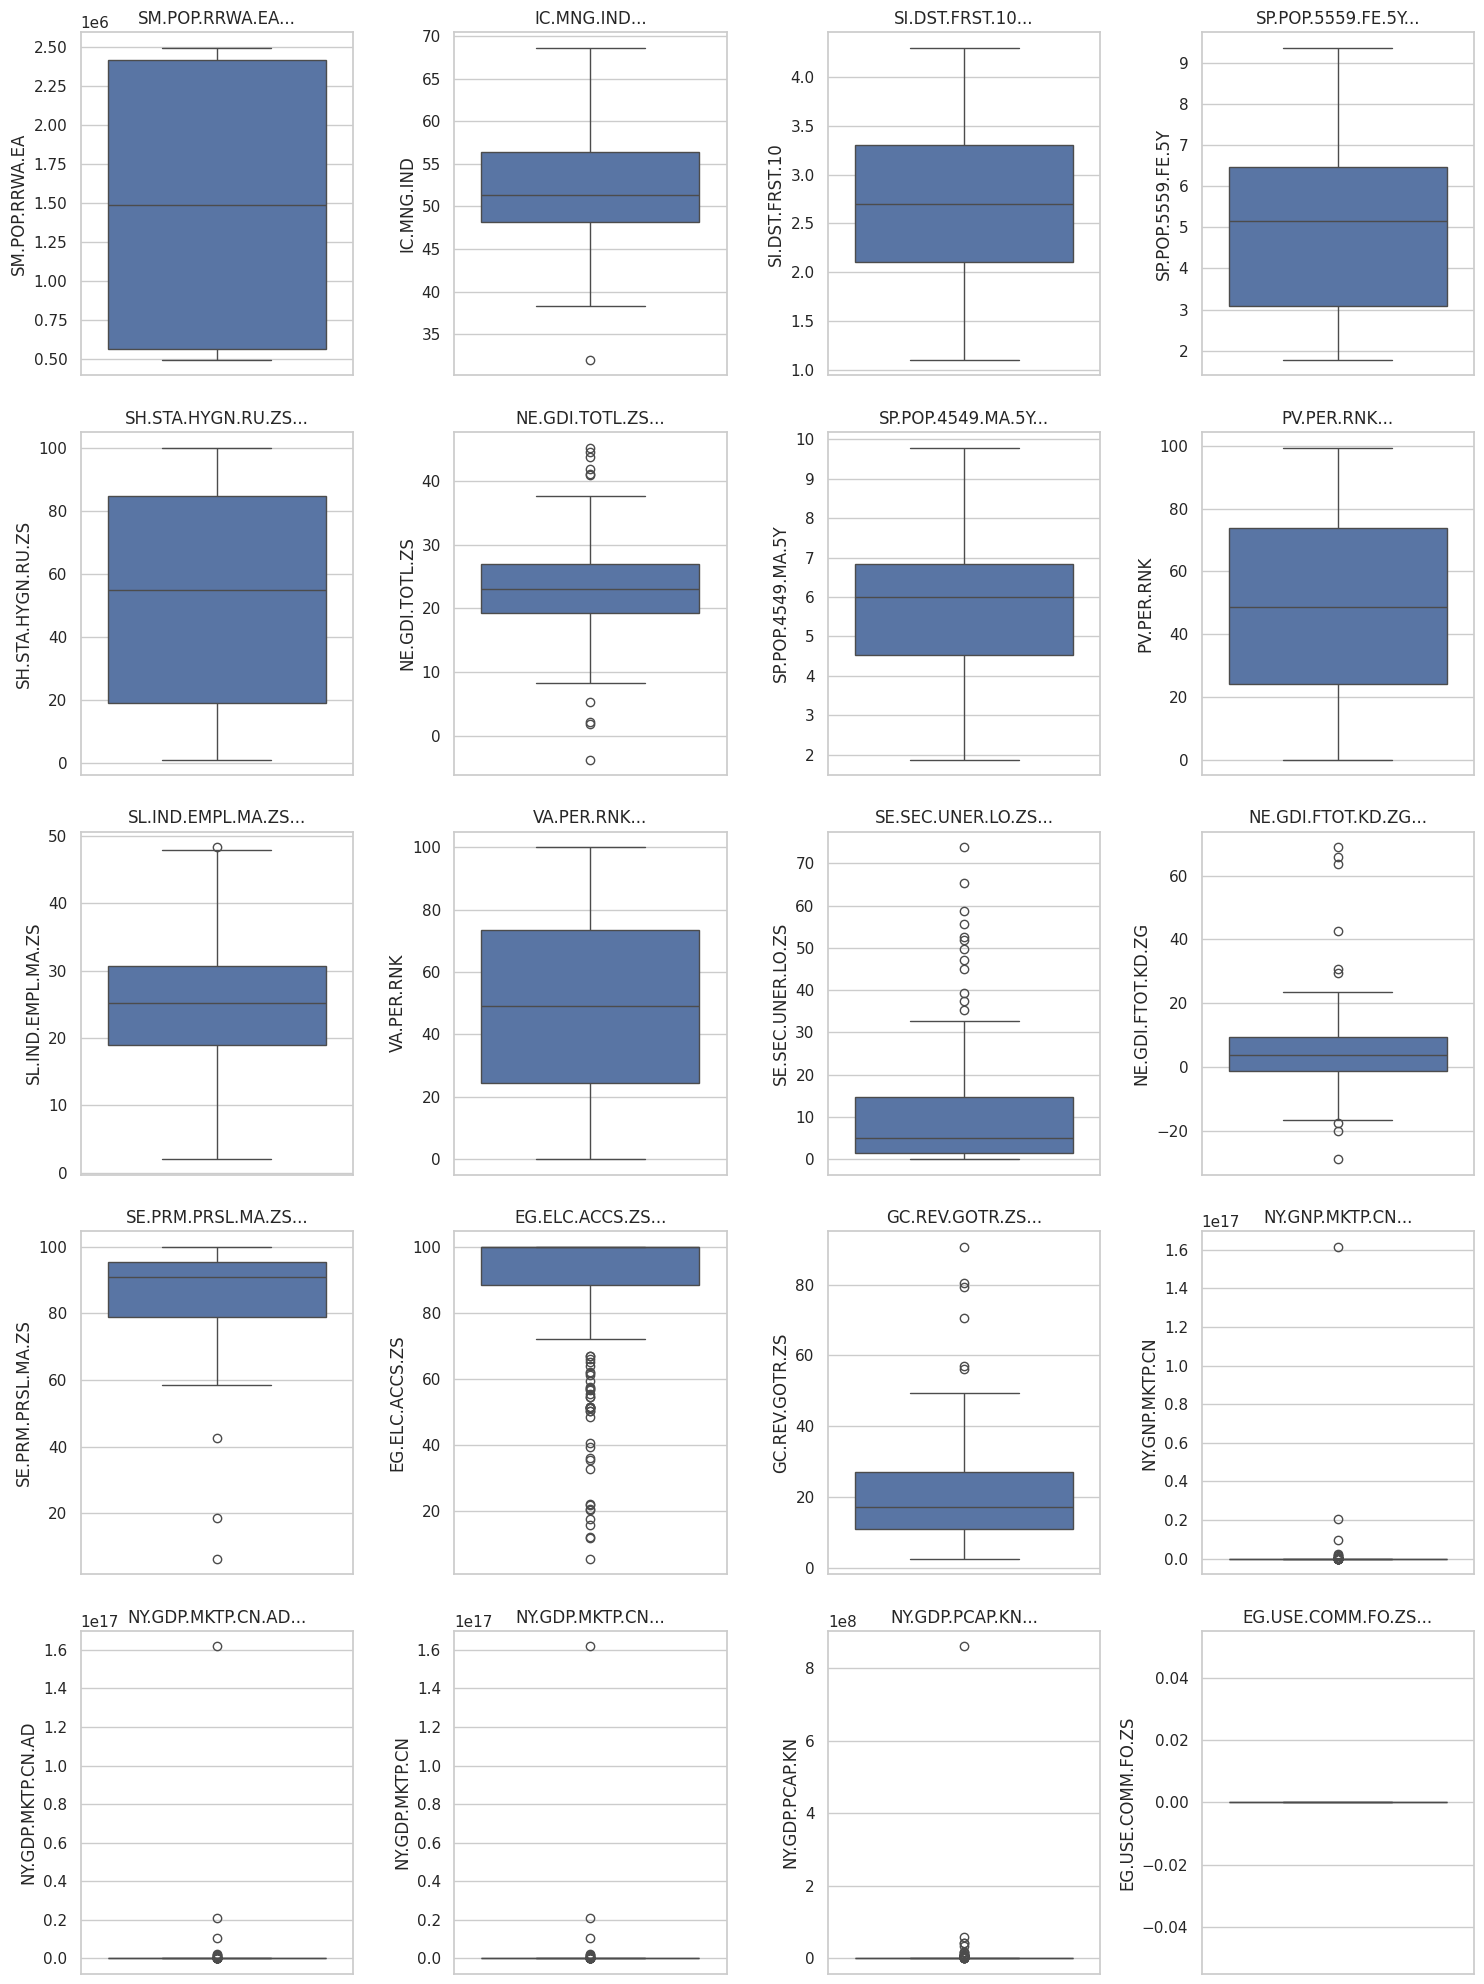

In [4]:
print("--- 1. Équilibre des classes ---")
N = len(df_final)
for classe, nk in df_final['Income_Group'].value_counts(dropna=False).items():
    print(f"Classe '{classe}' : {nk} pays ({nk/N*100:.2f}%)")

print("\n--- 2. Calcul Skewness, Kurtosis et Boxplots ---")
skew_kurt = {}
for col in cols_indicateurs:
    data = df_final[col].dropna()
    if len(data) > 3:
        skew_kurt[col] = {'Skewness': skew(data), 'Kurtosis': kurtosis(data)}
        
df_forme = pd.DataFrame(skew_kurt).T
df_forme['Abs_Skewness'] = pd.to_numeric(df_forme['Skewness']).abs()
df_sorted = df_forme.sort_values(by='Abs_Skewness')

# Sélection d'échantillons pour l'affichage (Extrêmes et Médianes)
selected_cols = df_sorted.head(10).index.tolist() + df_sorted.iloc[len(df_sorted)//2 - 2 : len(df_sorted)//2 + 3].index.tolist() + df_sorted.tail(5).index.tolist()

plt.figure(figsize=(15, math.ceil(len(selected_cols)/4) * 4))
for i, col in enumerate(selected_cols, 1):
    plt.subplot(math.ceil(len(selected_cols)/4), 4, i)
    sns.boxplot(y=df_final[col])
    plt.title(f"{col[:30]}...") 
plt.tight_layout()
plt.show()

# Séparation Train / Test
Nous encodons notre cible de manière ordinale (car la richesse suit un ordre logique). Ensuite, nous séparons les données (80% Train, 20% Test) avant de faire l'imputation et la normalisation.
Justification : C'est crucial pour éviter le Data Leakage (fuite de données). Les valeurs médianes et les paramètres de normalisation doivent être calculés uniquement sur le jeu d'entraînement pour simuler un scénario réel de prédiction.
du jeu d'entraînement. Si on découvre que la variable A et la variable B sont corrélées à 0.90 sur le Train, on décide de supprimer B. Ensuite, on supprime cette même colonne B dans le Train et dans le Test.

In [5]:
# Encodage de la cible
mapping = {
    "Faible revenu": 0, "Low income": 0,
    "Revenu intermédiaire, tranche inférieure": 1, "Lower middle income": 1,
    "Revenu intermédiaire, tranche supérieure": 2, "Upper middle income": 2,
    "Revenu élevé": 3, "High income": 3, 
    "Non classifié": 4, "Not classified": 4
}
df_final['Income_Group'] = df_final['Income_Group'].map(mapping)

# Suppression des pays non classifiés ou sans label
df_final = df_final.dropna(subset=['Income_Group'])

# Séparation Features (X) / Cible (y)
X = df_final.drop(columns=['Country_code', 'Income_Group'])
y = df_final['Income_Group']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Dimensions Train : X={X_train.shape}, y={y_train.shape}")
print(f"Dimensions Test  : X={X_test.shape}, y={y_test.shape}")

Dimensions Train : X=(173, 1516), y=(173,)
Dimensions Test  : X=(44, 1516), y=(44,)


# Pipeline de Pré-traitement
Sur nos données d'entraînement, nous appliquons séquentiellement :
    1. Imputation Smart : Suppression des colonnes >50% vides, puis remplissage des valeurs restantes par la médiane.
    2. Filtrage des corrélations : Suppression des variables redondantes ($|r| > 0.8$) pour lutter contre le fléau de la dimension.
    3. Standardisation (Z-Score) : Indispensable pour l'algorithme k-NN qui utilise la distance Euclidienne.

## Justification du choix de la Médiane

Face aux colonnes incomplètes conservées (moins de 50% de NaN originels calculés sur le Train), l'imputation s'effectue par la **médiane** calculée sur `X_train`.
*Pourquoi ?* Contrairement à la moyenne, la médiane est extrêmement rigide face aux outliers. Dans un groupe où vous avez 10 pays pauvres et 1 pays riche, la moyenne ne représente personne. La médiane, elle, représente le pays "typique" du groupe, ce qui est beaucoup plus robuste pour un classifieur de proximité comme k-NN.

## Justification de la Standardisation Z-Score

 Bien que le `Min-Max` soit pertinent pour contraindre strictement dans [0, 1], il est dramatiquement vulnérable aux valeurs aberrantes (un seul outlier gigantesque écrase la répartition de tout le reste du dataset). Le Z-score permet de normaliser spatialement les données (moyenne = 0, écart-type = 1) tout en conservant la structure des distributions, garantissant une meilleure évaluation des distances (k-NN).



In [7]:
# 1. Gestion des NaN
seuil_nan = 0.50
limite_non_na = len(X_train) * (1 - seuil_nan)

# Supprimer les colonnes avec plus de 50% de NaN
X_train_clean = X_train.dropna(thresh=limite_non_na, axis=1)
colonnes_conservees = X_train_clean.columns

X_test_clean = X_test[colonnes_conservees].copy()

for col in colonnes_conservees:
    median_value = X_train_clean[col].median(skipna=True)
    X_train_clean[col] = X_train_clean[col].fillna(median_value)
    X_test_clean[col] = X_test_clean[col].fillna(median_value)

print(f"{len(X_train.columns) - len(colonnes_conservees)} colonnes supprimées (>50% NaN).")

# 2. Variables corrélées
corr_matrix = X_train_clean.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

X_train_filtered = X_train_clean.drop(columns=to_drop)
X_test_filtered = X_test_clean.drop(columns=to_drop)
print(f"{len(to_drop)} attributs fortement corrélés supprimés. Features restantes: {len(X_train_filtered.columns)}")

# 3. Standardisation
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_filtered), columns=X_train_filtered.columns, index=X_train_filtered.index)
# On applique le transform (sans fit) sur le jeu de test
X_test_scaled = pd.DataFrame(scaler.transform(X_test_filtered), columns=X_test_filtered.columns, index=X_test_filtered.index)

/tmp/ipykernel_530281/3494510382.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_clean[col] = X_train_clean[col].fillna(median_value)
/tmp/ipykernel_530281/3494510382.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_clean[col] = X_train_clean[col].fillna(median_value)
/tmp/ipykernel_530281/3494510382.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

800 colonnes supprimées (>50% NaN).
470 attributs fortement corrélés supprimés. Features restantes: 246



--- Génération des histogrammes de comparaison Train vs Test ---
-> Image 'train_test_distributions.png' générée.


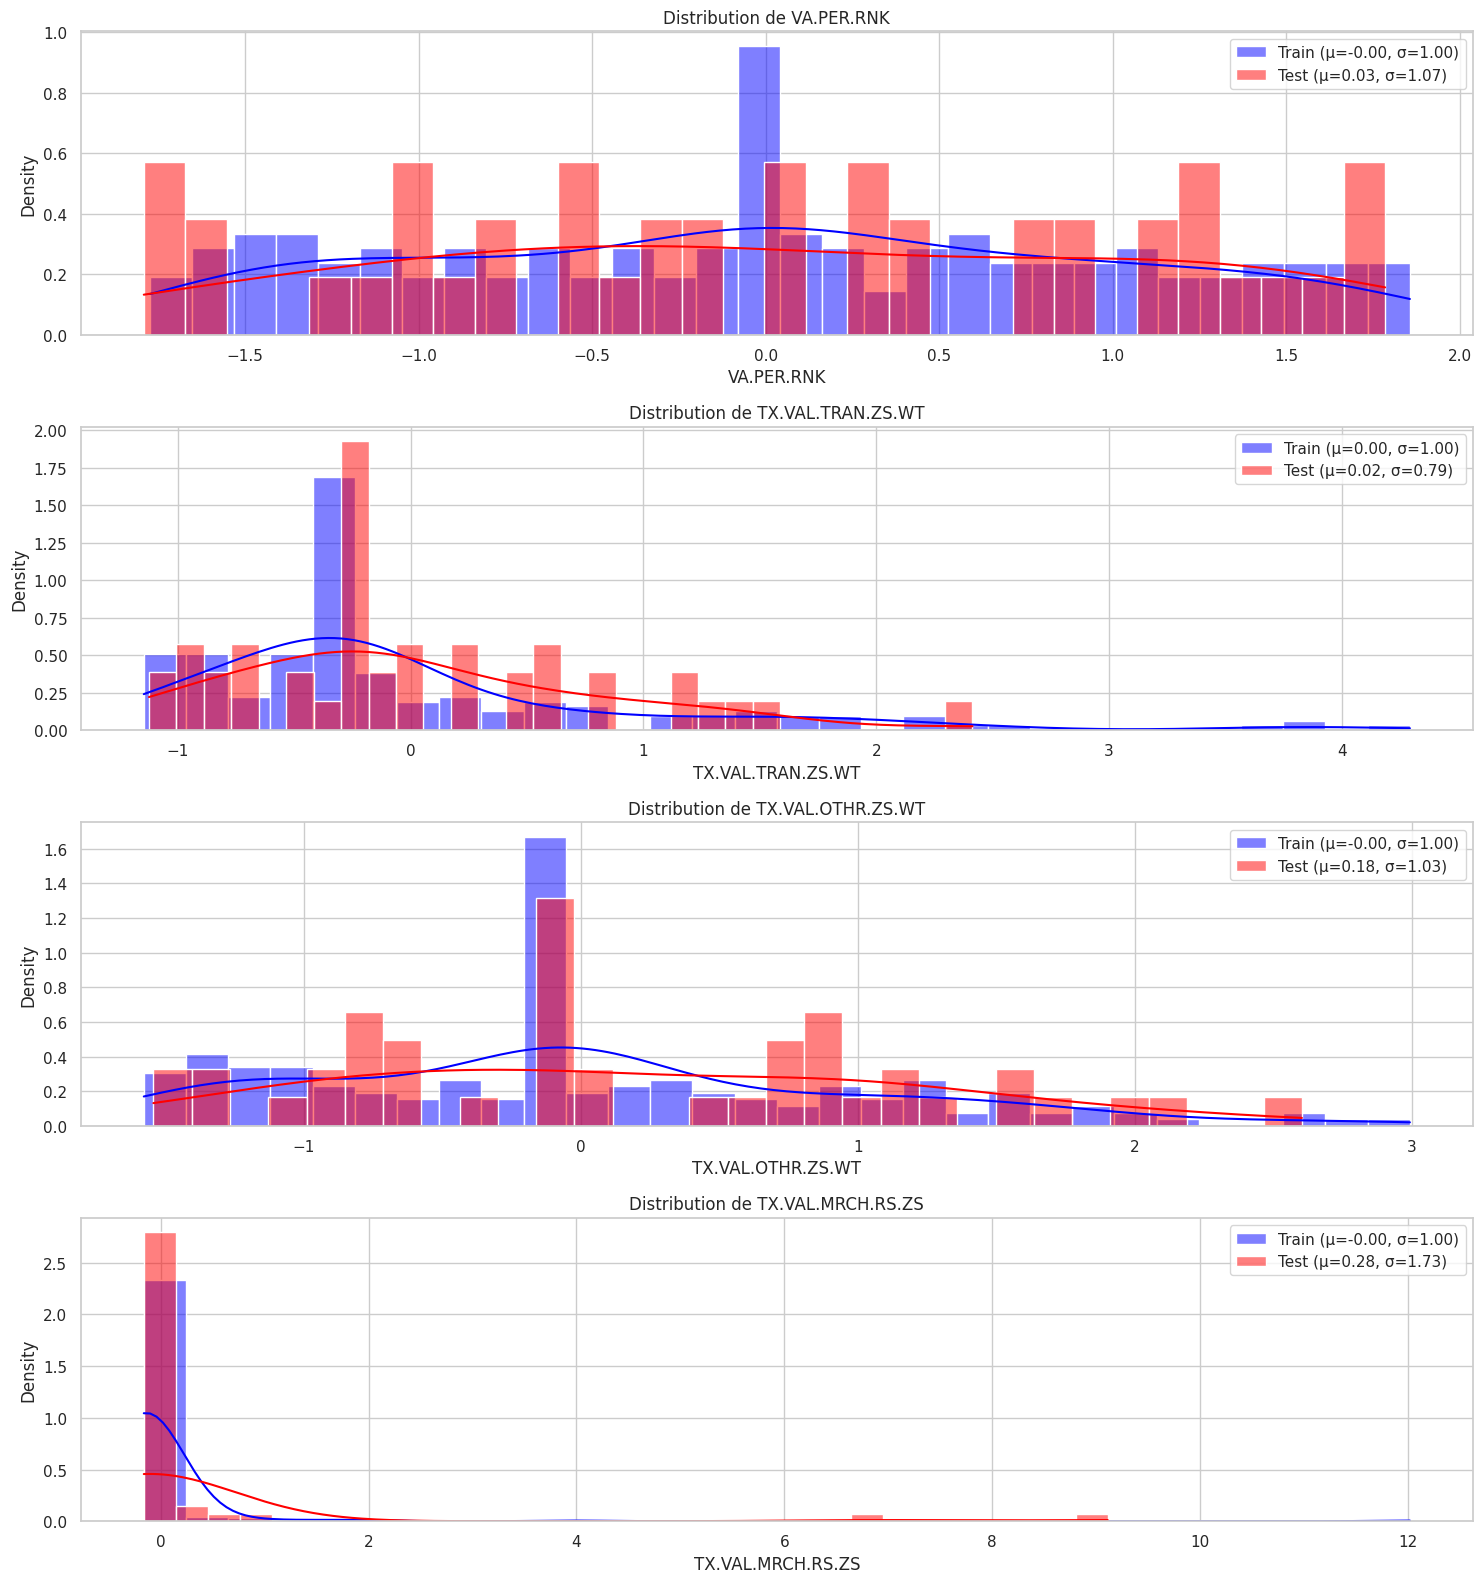

In [10]:
    print("\n--- Génération des histogrammes de comparaison Train vs Test ---")
    # JUSTIFICATION : Vérifier visuellement que la standardisation a bien fonctionné (moyennes proches de 0, écart-types proches de 1),
    # et que les distributions de Train et Test sont similaires (pas de dérive majeure lors du split).
    features_to_plot = X_train_scaled.columns[:4]
    plt.figure(figsize=(15, 4 * len(features_to_plot)))
    
    for i, col in enumerate(features_to_plot, 1):
        plt.subplot(len(features_to_plot), 1, i)
        sns.histplot(X_train_scaled[col], color="blue", label=f"Train (µ={X_train_scaled[col].mean():.2f}, σ={X_train_scaled[col].std():.2f})", kde=True, stat="density", bins=30, alpha=0.5)
        sns.histplot(X_test_scaled[col], color="red", label=f"Test (µ={X_test_scaled[col].mean():.2f}, σ={X_test_scaled[col].std():.2f})", kde=True, stat="density", bins=30, alpha=0.5)
        plt.title(f"Distribution de {col}")
        plt.legend()
        
    plt.tight_layout()
    plt.savefig("./train_test_distributions.png")
    print("-> Image 'train_test_distributions.png' générée.")

# Entraînement et Évaluation du modèle k-NN
Nous testons plusieurs valeurs de $k$ (nombre de voisins) pour trouver le meilleur compromis. Le modèle final est ensuite évalué sur le jeu de test à l'aide d'une matrice de confusion.

**Remarque** : L'algorithme k-NN est un apprentissage paresseux. Il calcule les distances Euclidiennes lors de la prédiction en se basant sur notre espace préalablement normalisé.



Le seul levier d’optimisation du k-NN est le nombre de voisins k. Pour éviter le
sur-apprentissage (overfitting) ou une simplification excessive (underfitting) par le modele, nous
procédons à une recherche itérative sur une plage de valeurs : k ∈ {1, 3, 5, . . . , 15}.
- Critère de sélection : L’exactitude (accuracy) mesurée sur le jeu
d’entraînement pour identifier la capacité du modèle à classifier les données
connues avant validation finale.
- Métrique de distance : Nous utilisons la distance Euclidienne donnee par:

    $$d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$

## Justification 
Distance Euclidienne est choisie car les données sont standardisées (Z-score). Elle correspond à la distance en ligne droite (à vol d'oiseau) entre deux points dans l'espace multidimensionnel formé par tes indicateurs économiques.
Dans un espace où chaque axe a une variance de 1, la distance "en ligne droite" est la plus naturelle.


--- Performances selon k ---
    k  Exactitude
0   1    0.704545
1   3    0.727273
2   5    0.704545
3   7    0.590909
4   9    0.568182
5  11    0.568182
6  13    0.522727
7  15    0.545455

Meilleur paramètre sélectionné : k = 3


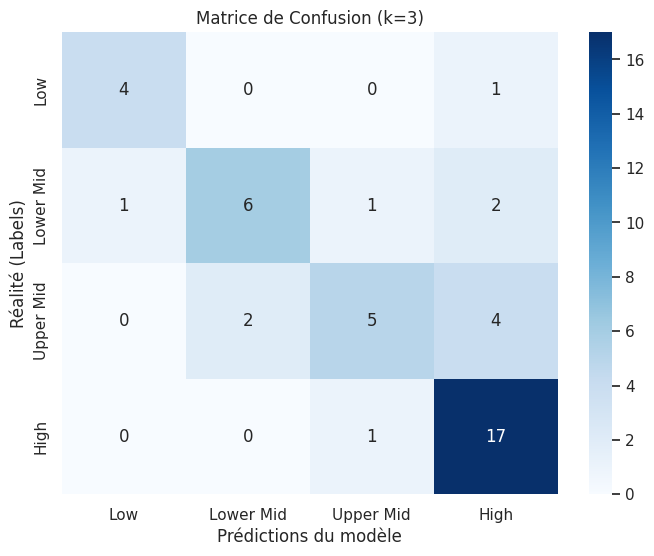

In [8]:
ks = [1, 3, 5, 7, 9, 11, 13, 15]
resultats_accuracy = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    resultats_accuracy.append({"k": k, "Exactitude": acc})

df_performance = pd.DataFrame(resultats_accuracy)
print("\n--- Performances selon k ---")
print(df_performance)

# Visualisation avec le meilleur k
meilleur_k = df_performance.loc[df_performance['Exactitude'].idxmax(), 'k']
print(f"\nMeilleur paramètre sélectionné : k = {meilleur_k}")

best_knn = KNeighborsClassifier(n_neighbors=int(meilleur_k), metric='euclidean')
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

# Matrice de confusion
plt.figure(figsize=(8, 6))
labels = ["Low", "Lower Mid", "Upper Mid", "High", "Not Classified"]
# On limite les labels affichés à ceux réellement présents dans y_test
labels_presents = [labels[int(i)] for i in sorted(y_test.unique())]

sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels_presents, yticklabels=labels_presents)
plt.xlabel('Prédictions du modèle')
plt.ylabel('Réalité (Labels)')
plt.title(f'Matrice de Confusion (k={int(meilleur_k)})')
plt.show()